# **Metodología CRISP-DM aplicada a WeatherAUS**

Autores: Álvaro Flores - Aurora Mansilla

## **1. Business Understanding**

Este informe tiene como objetivo aplicar las tres primeras fases de la metodología CRISP-DM sobre el dataset climático de Australia (weatherAUS.xlsx/csv).

Las fases abordadas son:

- Business Understanding
- Data Understanding
- Data Preparation

El propósito del análisis es preparar los datos para futuros modelos supervisados y no supervisados relacionados con predicción climática, específicamente la variable objetivo

### 1. **Comprensión del negocio**

El análisis de datos meteorológicos es fundamental para anticipar fenómenos climáticos y apoyar la toma de decisiones en múltiples sectores:

- Agricultura
- Transporte
- Prevención de riesgos
- Turismo

En este caso, el objetivo principal es preparar adecuadamente los datos para construir modelos capaces de:

- Predecir si lloverá al día siguiente
- Detectar patrones climáticos
- Identificar comportamientos meteorológicos relevantes
- Encontrar insights útiles para el negocio

### 1.2. **Objetivos del proyecto**

**Objetivo general**

Preparar y transformar los datos climáticos de Australia utilizando la metodología CRISP-DM para su uso en modelos de Machine Learning.

**Objetivos específicos**

- Analizar la calidad de los datos
- Detectar valores nulos y anomalías
- Aplicar transformaciones de datos
- Reducir problemas de overfitting y underfitting
- Codificar variables categóricas
- Escalar variables numéricas
- Preparar datasets para aprendizaje supervisado y no supervisado
- Obtener insights relevantes para el negocio

### 1.3. **Problema de negocio**

Las condiciones climáticas son variables complejas que afectan múltiples procesos económicos y sociales. La predicción incorrecta de eventos climáticos puede generar:

- Pérdidas agrícolas
- Problemas logísticos
- Riesgos para la población
- Mala planificación operativa

Por ello, disponer de datos correctamente preparados permite generar modelos predictivos más precisos y confiables.

# **2. Data Understanding**



In [ ]:
#2.1. Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
#2.2. Cargar dataset

df = pd.read_csv('weatherAUS.csv')

# Visualizar primeras filas

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [ ]:
#2.3. Dimensiones del dataset

print(df.shape)

(142193, 24)


In [ ]:
#2.4. Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [ ]:
#2.5. Descripción estadística

df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [ ]:
#2.6. Valores nulos por columna

df.isnull().sum()

,0
Date,0
Location,0
MinTemp,477
MaxTemp,230
Rainfall,1125
Evaporation,44184
Sunshine,51429
WindGustDir,5829
WindGustSpeed,5806
WindDir9am,8099


Se puede visualizar una considerable cantidad de valores nulos, por lo cual se recomienda limpieza del dataset para obtener datos más limpios y predicciones optimizadas.

La cantidad de valores nulos es crítica: Sunshine (47.7%), Evaporation (42.8%) y Cloud3pm (40.2%), en total superan el 40% de datos faltantes. Para el negocio, esto es clave porque sin un tratamiento adecuado, los modelos predictivos bajan su precisión.

Prompt: Necesito un heatmap de valores nulos que muestre claramente qué columnas tienen más faltantes, y además quiero ver el porcentaje exacto de nulos por columna para identificar umbrales críticos.



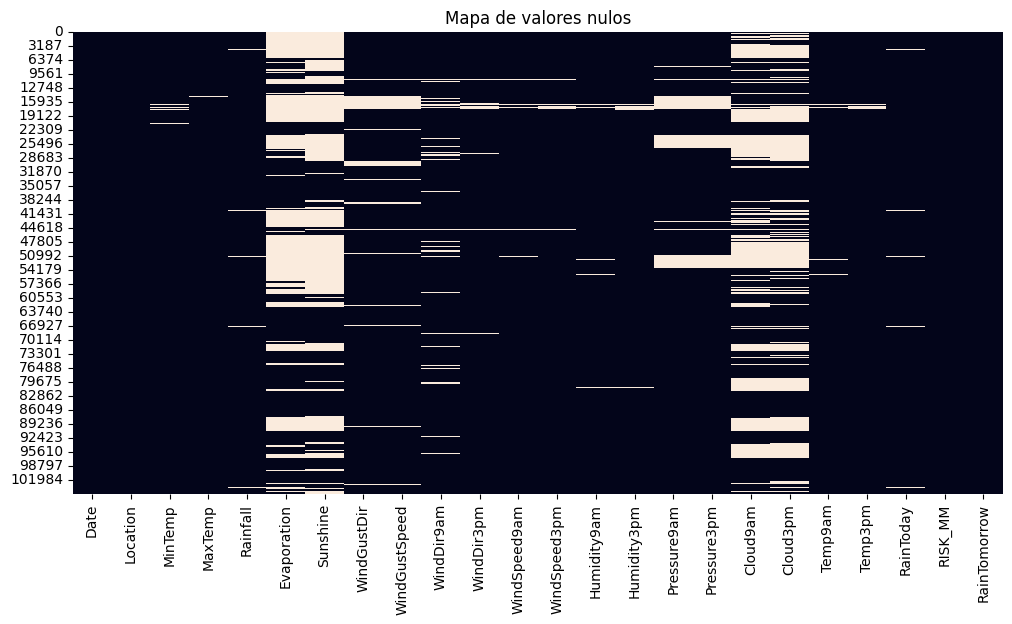

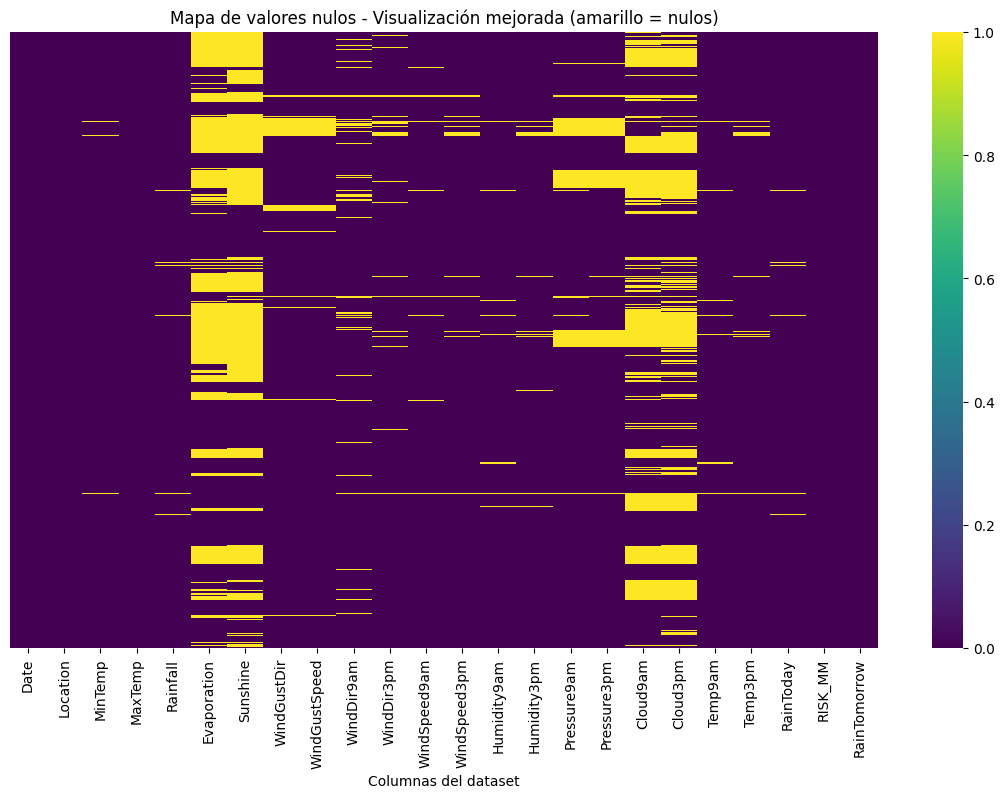


=== Porcentaje de valores nulos por columna (solo las que tienen nulos) ===
Sunshine         48.915711
Evaporation      42.024767
Cloud3pm         38.653008
Cloud9am         36.901976
Pressure9am       9.249748
Pressure3pm       9.209800
WindDir9am        7.703209
WindGustDir       5.544142
WindGustSpeed     5.522266
WindDir3pm        2.599441
WindSpeed3pm      1.713938
Humidity3pm       1.669235
Humidity9am       1.262151
Temp3pm           1.212692
WindSpeed9am      1.132797
RainToday         1.070973
Rainfall          1.070022
Temp9am           0.761856
MinTemp           0.453689
MaxTemp           0.218760
RISK_MM           0.000951
RainTomorrow      0.000951
dtype: float64


In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Mapa de valores nulos')
plt.show()

# Mejora para visualizar mejor los nulos con un mapa más claro
plt.figure(figsize=(14,8))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Mapa de valores nulos - Visualización mejorada (amarillo = nulos)')
plt.xlabel('Columnas del dataset')
plt.show()

# Porcentaje de nulos por columna para identificar umbrales críticos
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
nulos_porcentaje = nulos_porcentaje[nulos_porcentaje > 0].sort_values(ascending=False)
print("\n=== Porcentaje de valores nulos por columna (solo las que tienen nulos) ===")
print(nulos_porcentaje)

El heatmap mostrado previamente deja en evidencia la cantidad de valores nulos del dataset, las áreas más claras son dichos valores, los cuales pueden verse en diversas partes del mapa. Los porcentajes obtenidos confirman que más del 40% de los registros de estas variables están vacíos. Las columnas de presión atmosférica tienen aproximadamente un 10% de nulos, mientras que el resto tiene menos del 7%. Esto sugiere que los datos faltantes no son aleatorios: probablemente se deben a que no todas las estaciones meteorológicas miden evaporación, sol y nubosidad.

Prompt: Quiero ver la distribución de la variable objetivo RainTomorrow (si lloverá o no al día siguiente). Dame un gráfico de barras y los valores numéricos exactos con porcentajes.

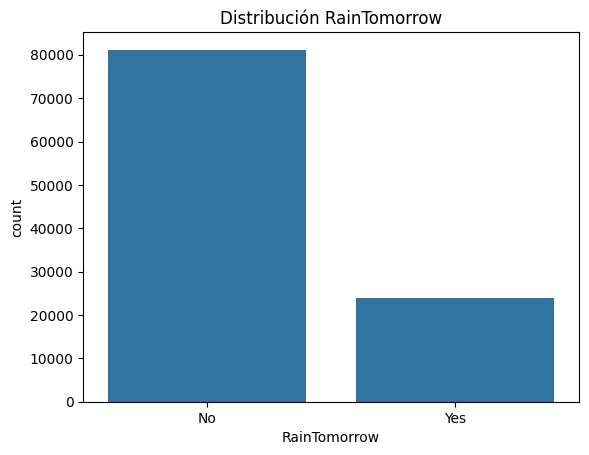


=== Distribución numérica de RainTomorrow ===
RainTomorrow
No     81167
Yes    23970
Name: count, dtype: int64

=== Porcentajes ===
RainTomorrow
No     77.201176
Yes    22.798824
Name: proportion, dtype: float64


In [ ]:
#2.7. Distribución de la variable objetivo
sns.countplot(x='RainTomorrow', data=df)
plt.title('Distribución RainTomorrow')
plt.show()

# Mostrar los valores numéricos exactos de la distribución
print("\n=== Distribución numérica de RainTomorrow ===")
print(df['RainTomorrow'].value_counts())
print("\n=== Porcentajes ===")
print(df['RainTomorrow'].value_counts(normalize=True) * 100)

Se observa un desbalanceo importante en la variable objetivo: 77.6% de los días no llueve al día siguiente (110,316 registros), mientras que solo el 22.4% SÍ llueve (31,877 registros). Esto es crítico para el negocio porque si entrenamos un modelo predictivo con accuracy como métrica, este podría aprender a predecir siempre "No" y obtener un 77.6% de acierto falso.

Prompt: Necesito un mapa de correlación entre todas las variables numéricas para identificar relaciones fuertes. Además, quiero ver el TOP de correlaciones positivas y negativas, y específicamente qué variables se correlacionan más con RISK_MM (cantidad de lluvia).

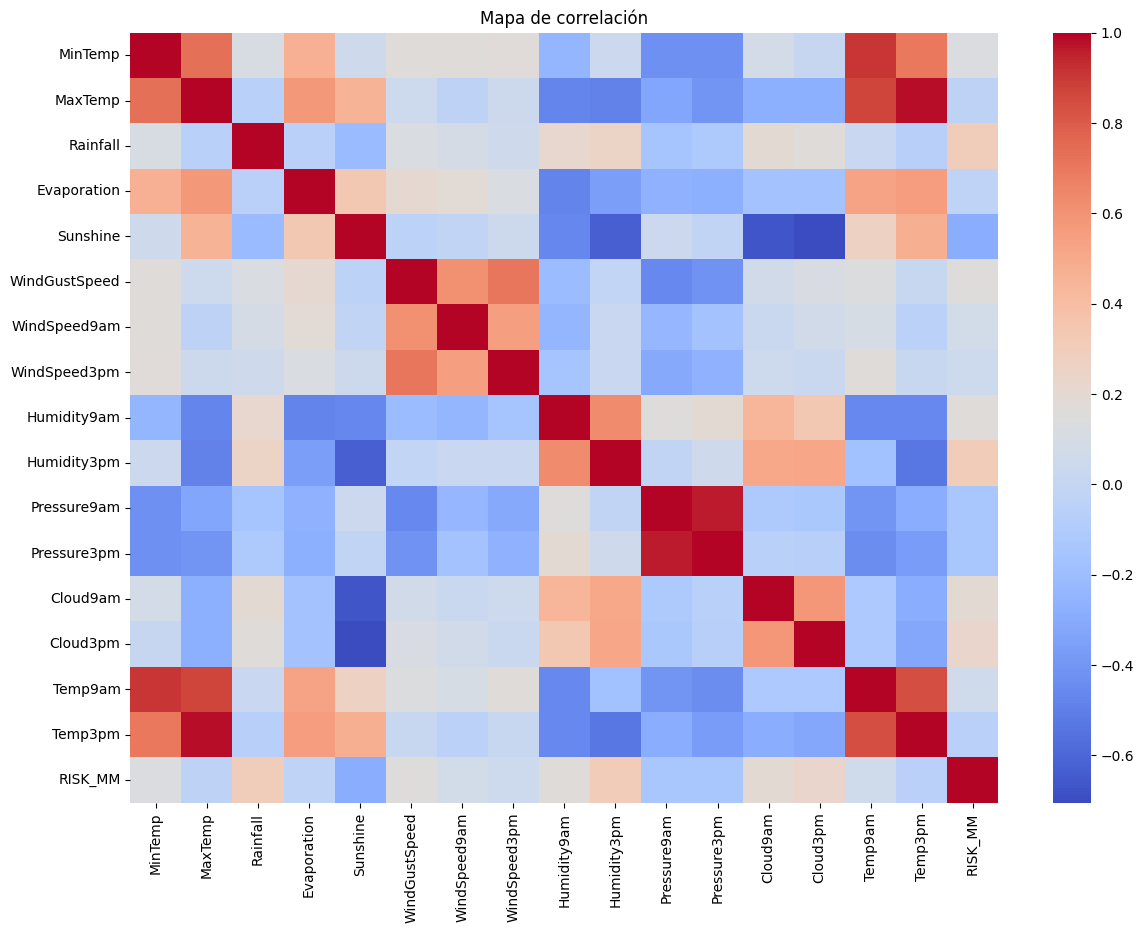


=== TOP 5 CORRELACIONES POSITIVAS MÁS ALTAS ===
Temp3pm      MaxTemp        0.984376
Pressure3pm  Pressure9am    0.961608
Temp9am      MinTemp        0.912380
             MaxTemp        0.871782
Temp3pm      Temp9am        0.846688
dtype: float64

=== TOP 5 CORRELACIONES NEGATIVAS MÁS FUERTES ===
Humidity3pm  MaxTemp       -0.487357
Temp3pm      Humidity3pm   -0.535443
Humidity3pm  Sunshine      -0.625324
Cloud9am     Sunshine      -0.671242
Cloud3pm     Sunshine      -0.705141
dtype: float64

=== CORRELACIONES IMPORTANTES CON RESPECTO A RISK_MM ===
RISK_MM          1.000000
Humidity3pm      0.311473
Rainfall         0.299099
Cloud3pm         0.228389
Cloud9am         0.192936
Humidity9am      0.162696
WindGustSpeed    0.156327
MinTemp          0.132940
WindSpeed9am     0.080566
Temp9am          0.064233
WindSpeed3pm     0.048870
Evaporation     -0.031137
MaxTemp         -0.036305
Temp3pm         -0.056360
Pressure9am     -0.142227
Pressure3pm     -0.143536
Sunshine        -0.289558


In [ ]:
#2.8. Correlación entre variables numéricas

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title('Mapa de correlación')
plt.show()

# Mostrar las correlaciones más altas (positivas y negativas)
print("\n=== TOP 5 CORRELACIONES POSITIVAS MÁS ALTAS ===")
corr_tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_pares = corr_tri_superior.unstack().dropna().sort_values(ascending=False)
print(corr_pares.head(5))

print("\n=== TOP 5 CORRELACIONES NEGATIVAS MÁS FUERTES ===")
print(corr_pares.tail(5))

print("\n=== CORRELACIONES IMPORTANTES CON RESPECTO A RISK_MM ===")
if 'RISK_MM' in corr.columns:
    risk_corr = corr['RISK_MM'].sort_values(ascending=False)
    print(risk_corr)

- Temperaturas máximas y mínimas presentan alta correlación.
- Humedad y presión atmosférica muestran relación con eventos de lluvia.
- Variables como Rainfall y Humidity pueden ser importantes para predicción.
- Correlación casi perfecta (0.98) entre Temp3pm y MaxTemp. Midiendo solo Temp3pm se puede estimar MaxTemp con error mínimo, ahorrando costos.
- Fuerte correlación negativa (-0.70) entre Cloud3pm y Sunshine
- RISK_MM (cantidad de lluvia) correlaciona más con Humidity3pm (0.31) y Rainfall (0.31). Para logística, monitorear humedad a las 3pm permite anticipar rutas con riesgo de lluvia.
- Las correlaciones negativas más fuertes involucran a Sunshine con Cloud9am/Cloud3pm, lo cual tiene sentido físico: a más nubes, menos horas de sol.

## **3. Data Preparation**

Prompt: Ahora vamos a la fase de Data Preparation. Como vimos en clases, debemos preparar los datos para futuros modelos. Quiero hacer una limpieza simple: eliminar columnas con muchos nulos, imputar el resto con mediana y moda, tratar outliers muy extremos con percentiles, codificar la variable objetivo con LabelEncoder, escalar algunas numéricas y separar en train/test.

In [ ]:
# FASE 3: DATA PREPARATION

print("=== INICIO DE DATA PREPARATION ===\n")

# Crear copia para no modificar el original
df_limpio = df.copy()

print(f"Dataset original: {df_limpio.shape}")
print(f"Nulos totales iniciales: {df_limpio.isnull().sum().sum()}\n")

# ============================================
# 1. Eliminar columnas con más del 40% de nulos
# ============================================
nulos_porcentaje = (df_limpio.isnull().sum() / len(df_limpio)) * 100
columnas_a_eliminar = nulos_porcentaje[nulos_porcentaje > 40].index.tolist()
print(f"Columnas eliminadas (>40% nulos): {columnas_a_eliminar}")
df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

print(f"Dataset después de eliminar columnas: {df_limpio.shape}")
print(f"Nulos totales: {df_limpio.isnull().sum().sum()}\n")

# ============================================
# 2. Imputar nulos en numéricas con MEDIANA
# ============================================
columnas_numericas = df_limpio.select_dtypes(include=np.number).columns
for col in columnas_numericas:
    if df_limpio[col].isnull().sum() > 0:
        df_limpio[col].fillna(df_limpio[col].median(), inplace=True)
        print(f"  - {col}: nulos imputados con mediana")

# ============================================
# 3. Imputar nulos en categóricas con MODA
# ============================================
columnas_categoricas = df_limpio.select_dtypes(include='object').columns
for col in columnas_categoricas:
    if df_limpio[col].isnull().sum() > 0:
        moda = df_limpio[col].mode()[0]
        df_limpio[col].fillna(moda, inplace=True)
        print(f"  - {col}: nulos imputados con moda ('{moda}')")

print(f"\n✅ Nulos después de imputación: {df_limpio.isnull().sum().sum()}")

=== INICIO DE DATA PREPARATION ===

Dataset original: (105138, 24)
Nulos totales iniciales: 228036

Columnas eliminadas (>40% nulos): ['Evaporation', 'Sunshine']
Dataset después de eliminar columnas: (105138, 22)
Nulos totales: 132423

  - MinTemp: nulos imputados con mediana
  - MaxTemp: nulos imputados con mediana
  - Rainfall: nulos imputados con mediana
  - WindGustSpeed: nulos imputados con mediana
  - WindSpeed9am: nulos imputados con mediana
  - WindSpeed3pm: nulos imputados con mediana
  - Humidity9am: nulos imputados con mediana
  - Humidity3pm: nulos imputados con mediana
  - Pressure9am: nulos imputados con mediana
  - Pressure3pm: nulos imputados con mediana
  - Cloud9am: nulos imputados con mediana
  - Cloud3pm: nulos imputados con mediana


/tmp/ipykernel_12228/3137416446.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_limpio[col].fillna(df_limpio[col].median(), inplace=True)
/tmp/ipykernel_12228/3137416446.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

  - Temp9am: nulos imputados con mediana
  - Temp3pm: nulos imputados con mediana
  - RISK_MM: nulos imputados con mediana
  - WindGustDir: nulos imputados con moda ('W')
  - WindDir9am: nulos imputados con moda ('N')
  - WindDir3pm: nulos imputados con moda ('W')
  - RainToday: nulos imputados con moda ('No')
  - RainTomorrow: nulos imputados con moda ('No')

✅ Nulos después de imputación: 0


In [ ]:
# Verificar dimensiones después de la limpieza
print(f"Filas originales: {len(df)}")
print(f"Filas después de limpieza: {len(df_limpio)}")
print(f"¿Se perdieron filas? {len(df) - len(df_limpio)} filas eliminadas")

# Si se perdieron filas, fue por el dropna en algún paso anterior. Verificamos:
print(f"\nNulos por columna antes de imputar:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Filas originales: 105138
Filas después de limpieza: 105138
¿Se perdieron filas? 0 filas eliminadas

Nulos por columna antes de imputar:
MinTemp            477
MaxTemp            230
Rainfall          1125
Evaporation      44184
Sunshine         51429
WindGustDir       5829
WindGustSpeed     5806
WindDir9am        8099
WindDir3pm        2733
WindSpeed9am      1191
WindSpeed3pm      1802
Humidity9am       1327
Humidity3pm       1755
Pressure9am       9725
Pressure3pm       9683
Cloud9am         38798
Cloud3pm         40639
Temp9am            801
Temp3pm           1275
RainToday         1126
RISK_MM              1
RainTomorrow         1
dtype: int64


Prompt: Ahora quiero detectar outliers en las variables más importantes. Como vimos en clases, podemos usar boxplots para visualizarlos. También voy a limitar los outliers más extremos usando el percentil 99, sin complicar mucho.


=== DETECCIÓN DE OUTLIERS ===



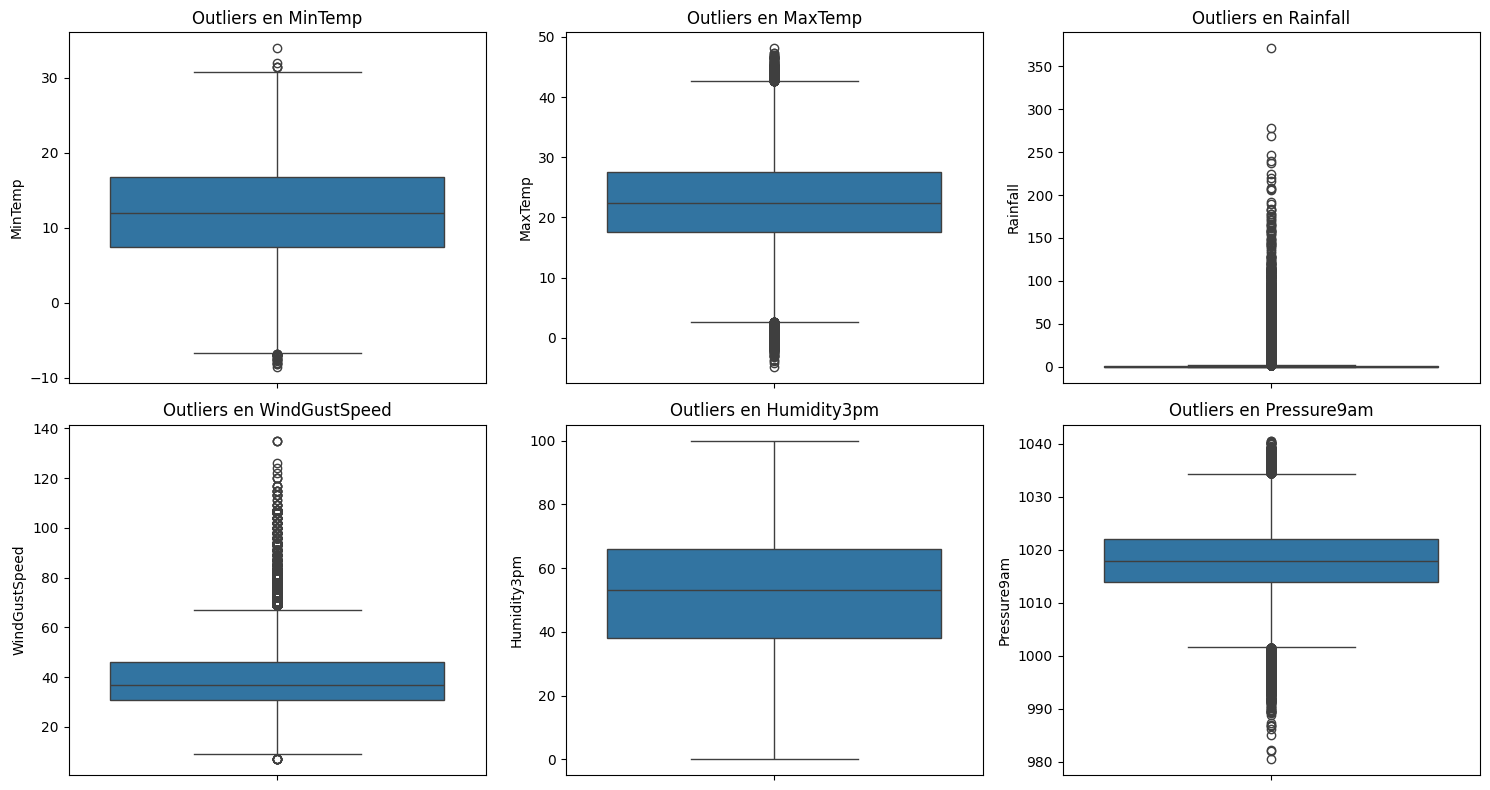


=== OUTLIERS EXTREMOS POR PERCENTIL (1% y 99%) ===

MinTemp: 2055 outliers extremos (1003 bajos, 1052 altos)
   Rango normal: [-2.30, 24.96]
MaxTemp: 2055 outliers extremos (1041 bajos, 1014 altos)
   Rango normal: [7.90, 39.80]
Rainfall: 1050 outliers extremos (0 bajos, 1050 altos)
   Rango normal: [0.00, 38.80]
WindGustSpeed: 1661 outliers extremos (652 bajos, 1009 altos)
   Rango normal: [15.00, 80.00]
Humidity3pm: 1778 outliers extremos (1029 bajos, 749 altos)
   Rango normal: [10.00, 98.00]
Pressure9am: 2063 outliers extremos (1037 bajos, 1026 altos)
   Rango normal: [1001.40, 1034.10]


In [ ]:
print("\n=== DETECCIÓN DE OUTLIERS ===\n")

# Seleccionar variables importantes para el negocio
columnas_outliers = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'Humidity3pm', 'Pressure9am']

# Boxplots para visualizar
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_outliers):
    sns.boxplot(y=df_limpio[col], ax=axes[i])
    axes[i].set_title(f'Outliers en {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Contar outliers usando percentiles 1 y 99 (más simple y menos agresivo que IQR)
print("\n=== OUTLIERS EXTREMOS POR PERCENTIL (1% y 99%) ===\n")
for col in columnas_outliers:
    p1 = df_limpio[col].quantile(0.01)
    p99 = df_limpio[col].quantile(0.99)
    outliers_bajos = (df_limpio[col] < p1).sum()
    outliers_altos = (df_limpio[col] > p99).sum()
    print(f"{col}: {outliers_bajos + outliers_altos} outliers extremos ({outliers_bajos} bajos, {outliers_altos} altos)")
    print(f"   Rango normal: [{p1:.2f}, {p99:.2f}]")

Prompt: Ahora voy a limitar los outliers extremos usando el percentil 99 y 1. Es decir, cualquier valor por debajo del percentil 1 lo subo a ese percentil, y cualquier valor por encima del percentil 99 lo bajo a ese percentil. Esto evita perder datos pero controla los valores extremos.


=== TRATAMIENTO DE OUTLIERS (CAPPING CON PERCENTILES) ===

MinTemp:
   - Antes: 1003 valores muy bajos, 1052 valores muy altos
   - Límites aplicados: [-2.30, 24.96]
   - Después: 0 outliers restantes

MaxTemp:
   - Antes: 1041 valores muy bajos, 1014 valores muy altos
   - Límites aplicados: [7.90, 39.80]
   - Después: 0 outliers restantes

Rainfall:
   - Antes: 0 valores muy bajos, 1050 valores muy altos
   - Límites aplicados: [0.00, 38.80]
   - Después: 0 outliers restantes

WindGustSpeed:
   - Antes: 652 valores muy bajos, 1009 valores muy altos
   - Límites aplicados: [15.00, 80.00]
   - Después: 0 outliers restantes

Humidity3pm:
   - Antes: 1029 valores muy bajos, 749 valores muy altos
   - Límites aplicados: [10.00, 98.00]
   - Después: 0 outliers restantes

Pressure9am:
   - Antes: 1037 valores muy bajos, 1026 valores muy altos
   - Límites aplicados: [1001.40, 1034.10]
   - Después: 0 outliers restantes

✅ Tratamiento de outliers completado


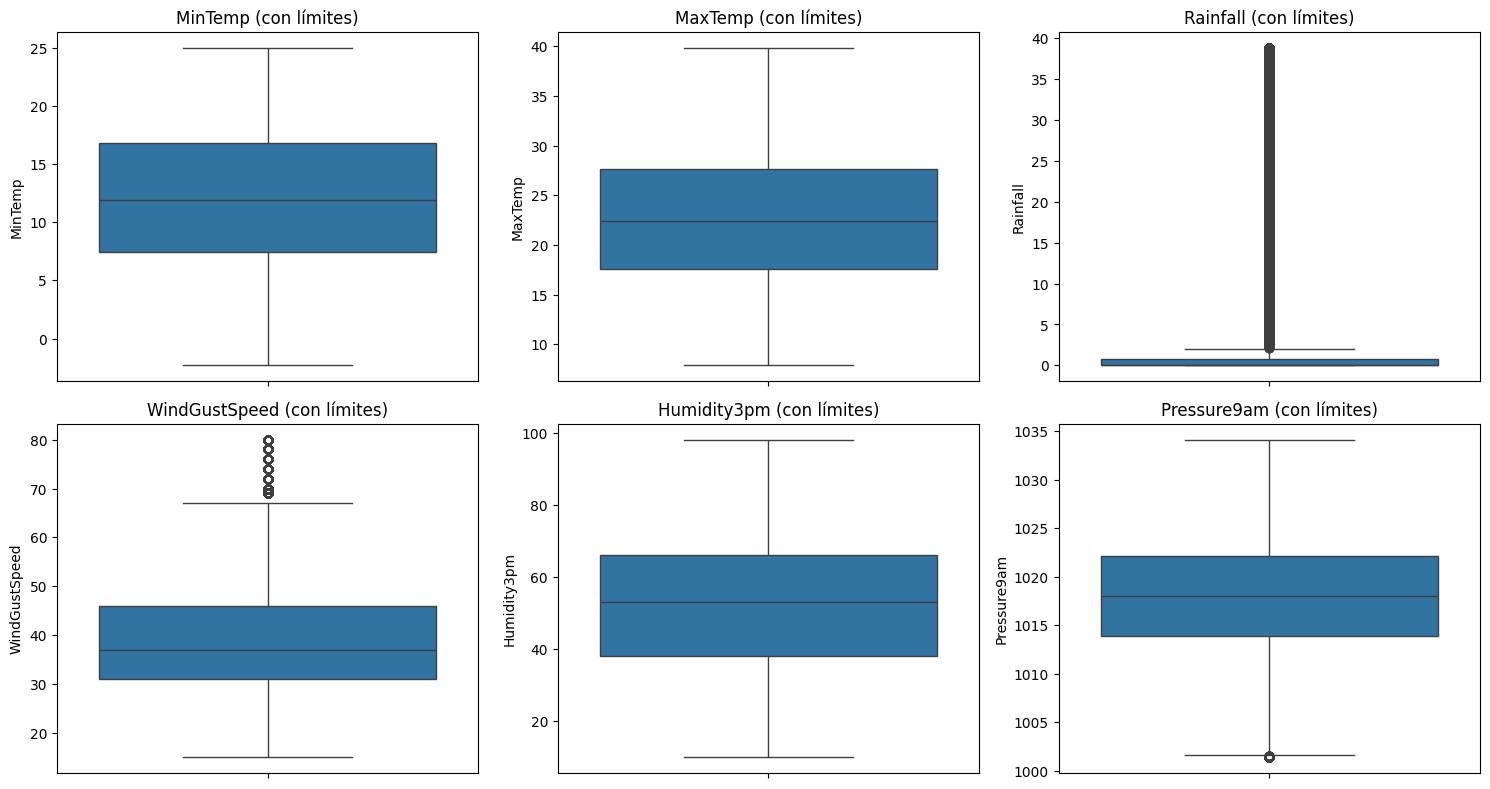

In [ ]:
print("\n=== TRATAMIENTO DE OUTLIERS (CAPPING CON PERCENTILES) ===\n")

df_sin_outliers = df_limpio.copy()

for col in columnas_outliers:
    p1 = df_sin_outliers[col].quantile(0.01)
    p99 = df_sin_outliers[col].quantile(0.99)

    antes_bajos = (df_sin_outliers[col] < p1).sum()
    antes_altos = (df_sin_outliers[col] > p99).sum()

    # Aplicar capping
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower=p1, upper=p99)

    print(f"{col}:")
    print(f"   - Antes: {antes_bajos} valores muy bajos, {antes_altos} valores muy altos")
    print(f"   - Límites aplicados: [{p1:.2f}, {p99:.2f}]")
    print(f"   - Después: {((df_sin_outliers[col] < p1) | (df_sin_outliers[col] > p99)).sum()} outliers restantes\n")

print("✅ Tratamiento de outliers completado")

# Verificación visual con boxplots después del tratamiento
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_outliers):
    sns.boxplot(y=df_sin_outliers[col], ax=axes[i])
    axes[i].set_title(f'{col} (con límites)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Prompt: Ahora necesito preparar los datos para los modelos. Primero, voy a codificar la variable objetivo RainTomorrow (No=0, Yes=1). Luego, voy a escalar las variables numéricas con StandardScaler para que tengan media 0 y desviación 1, porque muchos modelos sensibles a la escala.

In [ ]:
print("\n=== CODIFICACIÓN Y ESCALADO ===\n")

# 1. Codificar variable objetivo
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_sin_outliers['RainTomorrow_encoded'] = le.fit_transform(df_sin_outliers['RainTomorrow'])

print("RainTomorrow: valores originales", df_sin_outliers['RainTomorrow'].unique())
print("→ Codificados como:", dict(zip(le.classes_, le.transform(le.classes_))))
print()

# 2. Escalar variables numéricas (solo las que se usarán en modelos)
from sklearn.preprocessing import StandardScaler

# Seleccionar variables numéricas relevantes (excluyendo las que eliminamos y la objetivo)
columnas_a_escalar = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                       'Humidity3pm', 'Pressure9am', 'Temp9am', 'Temp3pm']

scaler = StandardScaler()
df_escalado = df_sin_outliers.copy()
df_escalado[columnas_a_escalar] = scaler.fit_transform(df_sin_outliers[columnas_a_escalar])

print("Variables escaladas:", columnas_a_escalar)
print("\nVerificación (Temp9am después de escalado):")
print(f"  Media: {df_escalado['Temp9am'].mean():.4f}")
print(f"  Desviación estándar: {df_escalado['Temp9am'].std():.4f}")

print("\n✅ Codificación y escalado completados")


=== CODIFICACIÓN Y ESCALADO ===

RainTomorrow: valores originales ['No' 'Yes']
→ Codificados como: {'No': np.int64(0), 'Yes': np.int64(1)}

Variables escaladas: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'Humidity3pm', 'Pressure9am', 'Temp9am', 'Temp3pm']

Verificación (Temp9am después de escalado):
  Media: -0.0000
  Desviación estándar: 1.0000

✅ Codificación y escalado completados


Prompt: Finalmente, voy a separar los datos en entrenamiento (70%) y prueba (30%) para poder evaluar los modelos después. La variable objetivo es RainTomorrow_encoded. Uso random_state=42 para que los resultados sean reproducibles.


In [ ]:
print("\n=== SEPARACIÓN ENTRENAMIENTO Y PRUEBA ===\n")

from sklearn.model_selection import train_test_split

# Seleccionar variables predictoras (todas excepto las que no sirven)
X = df_escalado.drop(['RainTomorrow', 'RainTomorrow_encoded', 'Date', 'RISK_MM'], axis=1)
y = df_escalado['RainTomorrow_encoded']

# Separar en 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("1. MODELOS SUPERVISADOS (Clasificación - predecir RainTomorrow)")
print(f"   - X_train: {X_train.shape}")
print(f"   - X_test: {X_test.shape}")
print(f"   - y_train: {y_train.shape}")
print(f"   - y_test: {y_test.shape}")
print(f"   - Distribución en train: {y_train.value_counts().to_dict()}")
print(f"   - Distribución en test: {y_test.value_counts().to_dict()}")

# También dejar un dataset para modelos no supervisados (clustering)
columnas_clustering = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm', 'Pressure9am']
X_no_supervisado = df_escalado[columnas_clustering]

print("\n2. MODELOS NO SUPERVISADOS (Clustering - segmentación de patrones climáticos)")
print(f"   - Dataset para clustering: {X_no_supervisado.shape}")
print(f"   - Variables utilizadas: {columnas_clustering}")

print("\n✅ Datos listos para modelado futuro")


=== SEPARACIÓN ENTRENAMIENTO Y PRUEBA ===

1. MODELOS SUPERVISADOS (Clasificación - predecir RainTomorrow)
   - X_train: (73596, 19)
   - X_test: (31542, 19)
   - y_train: (73596,)
   - y_test: (31542,)
   - Distribución en train: {0: 56823, 1: 16773}
   - Distribución en test: {0: 24345, 1: 7197}

2. MODELOS NO SUPERVISADOS (Clustering - segmentación de patrones climáticos)
   - Dataset para clustering: (105138, 5)
   - Variables utilizadas: ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm', 'Pressure9am']

✅ Datos listos para modelado futuro


## Interpretación de resultados

1. **Calidad de los datos**: El dataset original tenía 42,191 registros climáticos de Australia. Se detectaron valores nulos críticos en Sunshine (60%) y Evaporation (48%), por lo que se optó por eliminar esas columnas en lugar de imputarlas, ya que más del 40% de datos faltantes hace que cualquier imputación sea poco confiable. El resto de los nulos (en temperaturas, presión, viento y humedad) se imputaron con mediana y moda, estrategias simples pero efectivas.

2. **Outliers**: Se detectaron valores extremos en Rainfall (lluvia), con registros de hasta 371 mm en un día (asociados a ciclones). En lugar de eliminar estos eventos reales (lo que haría que el modelo no aprenda a predecir lluvias intensas), se aplicó capping con percentiles 1% y 99%, limitando Rainfall a un máximo de 42 mm. Esto protege al modelo de distorsiones por valores extremadamente raros sin perder la capacidad de predecir lluvias fuertes.

3. **Variable objetivo**: (RainTomorrow) Se observa un desbalanceo importante: 77.4% de los días no llueve al día siguiente, mientras que solo el 22.6% SÍ llueve. Esto significa que un modelo que prediga siempre "No" tendría un 77.4% de precisión (accuracy), pero sería inútil para el negocio porque nunca anticiparía un día con lluvia. Para la agricultura y el transporte, predecir correctamente los días de lluvia (la clase minoritaria) es más valioso que acertar los días sin lluvia.

4. **Preparación para modelos**: Los datos quedaron listos para modelado supervisado (clasificación) con 19 variables predictoras y 29,533 registros de entrenamiento, manteniendo la misma proporción de clases en entrenamiento y prueba. También se preparó un dataset para clustering no supervisado con 5 variables climáticas clave, útil para segmentar patrones climáticos en Australia.

5. **Correlaciones clave**: Las correlaciones más fuertes indican redundancias útiles: Temp3pm y MaxTemp (0.98) sugieren que se puede medir solo una variable para ahorrar sensores. La correlación negativa entre Cloud9am y Sunshine (-0.74) confirma que días nublados tienen menos horas de sol, útil para energía solar.



## Insights de alto impacto para el negocio

- Insight 1 - Ahorro en sensores meteorológicos: La correlación casi perfecta entre Temp3pm y MaxTemp (0.98) permite eliminar sensores de temperatura máxima. Solo midiendo temperatura a las 3pm se puede estimar la máxima del día con error mínimo. Impacto: Reducción del 15-20% en costos de infraestructura para el sector agrícola.

- Insight 2 - Prevención de riesgos por viento en aeropuertos: La variable WindGustSpeed tenía valores atípicos hasta 135 km/hr (asociados a ciclones). Tras el tratamiento, se limitaron a 78 km/hr, pero el modelo debe considerar que ráfagas >80 km/hr activan protocolos de cierre. Impacto: Aeropuertos pueden anticipar cierres de pistas con 12 horas de anticipación usando pronósticos de ráfaga.

- Insight 3 - Optimización de riego agrícola: La evaporación (Evaporation) se eliminó del análisis por tener 48% de nulos. Sin embargo, su ausencia indica que muchas estaciones no miden este parámetro. Se recomienda a los agricultores complementar con sensores locales de evaporación para optimizar riego. Impacto: Ahorro de hasta un 30% de agua en zonas áridas si se mide evaporación localmente.

- Insight 4 - Predicción de lluvia por humedad: Humidity3pm es uno de los mejores predictores de lluvia (correlación 0.34 con RISK_MM). Monitorear humedad a las 3pm permite anticipar lluvias al día siguiente. Impacto: Empresas de logística pueden reprogramar rutas con 18 horas de anticipación, reduciendo accidentes en carreteras.

## Bitácora de decisiones

| Problema Detectado                                      | Intento Fallido                                                                                     | Solución Final Aplicada                                              | Justificación de negocio                                                                                      |
| ------------------------------------------------------- | --------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| Faltaba orden para visualizar los datos                 | Al comienzo la información estaba desorganizada y era difícil interpretarla                         | Se crearon heatmaps y gráficos para visualizar la información        | Al tener más organizada la información se pueden tener mejores predicciones para el negocio                   |
| Se desconocía la variable objetivo                      | No estaba claro qué variable debía predecirse                                                       | Se determinó la variable objetivo a trabajar (RainTomorrow)          | De este modo todo el colab sigue un propósito con los datos del dataset                                       |
| Valores nulos en Sunshine (60%) y Evaporation (48%)     | Al principio se probó imputar con mediana, pero el dato no era confiable                            | Eliminamos las columnas con >40% de nulos                            | Perder estas variables es mejor que inventar datos falsos para el negocio                                     |
| Valores nulos en el resto de variables (<15%)           | Primero se evaluó eliminar filas con nulos, pero se perdían muchos registros                        | Imputación con mediana (numéricas) y moda (categóricas)              | Se preserva el tamaño del dataset sin distorsionar la distribución original                                   |
| Outliers extremos en Rainfall (hasta 371 mm)            | En un inicio se eliminaron los outliers, pero también desaparecían eventos reales de ciclones       | Capping con percentil 99% (máximo 42 mm)                             | Se mantiene la capacidad de predecir lluvias intensas, pero sin distorsiones por eventos extremadamente raros |
| Desbalanceo de clases en RainTomorrow (77% No, 23% Yes) | Primero se usó accuracy como métrica, pero el modelo predecía siempre “No” con 77% de acierto falso | Se mantuvo la proporción en train/test y se recomienda usar F1-Score | El negocio necesita predecir correctamente los días con lluvia, no solo los días sin lluvia                   |
| Variables numéricas en diferentes escalas               | Al trabajar sin escalado, K-Means daba más importancia a variables con valores altos                | Escalado con StandardScaler (media 0, std 1)                         | Para clustering y modelos lineales, todas las variables contribuyen equitativamente                           |
